## Step 1: Import Necessary Libraries

In [ ]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns



## Step 2: Create a Synthesized Real Estate Dataset

In [ ]:

# Create a synthesized dataset
data = {
    'Lot size': [5000, 6000, 4500, 7000, 5500, 8000, 6500, 4800, 7200, 5800],
    'House type': ['Single Family', 'Townhouse', 'Condo', 'Single Family', 'Townhouse', 'Condo', 'Single Family', 'Townhouse', 'Single Family', 'Condo'],
    'Year built': [1990, 1985, 2000, 1975, 1995, 2005, 1980, 1998, 1970, 2010],
    'Last sold price': [250000, 300000, 200000, 350000, 275000, 400000, 320000, 220000, 380000, 260000],
    'Finished sqft': [1500, 1800, 1200, 2000, 1600, 2200, 1700, 1300, 2100, 1400],
    'Unfinished sqft': [500, 200, 300, 400, 600, 800, 500, 400, 700, 300],
    'Parking type': ['Garage', 'Driveway', 'Garage', 'Driveway', 'Garage', 'Driveway', 'Garage', 'Driveway', 'Garage', 'Driveway'],
    'Heating type': ['Central', 'Electric', 'Central', 'Electric', 'Central', 'Electric', 'Central', 'Electric', 'Central', 'Electric']
}

df = pd.DataFrame(data)
df


,Lot size,House type,Year built,Last sold price,Finished sqft,Unfinished sqft,Parking type,Heating type
0,5000,Single Family,1990,250000,1500,500,Garage,Central
1,6000,Townhouse,1985,300000,1800,200,Driveway,Electric
2,4500,Condo,2000,200000,1200,300,Garage,Central
3,7000,Single Family,1975,350000,2000,400,Driveway,Electric
4,5500,Townhouse,1995,275000,1600,600,Garage,Central
5,8000,Condo,2005,400000,2200,800,Driveway,Electric
6,6500,Single Family,1980,320000,1700,500,Garage,Central
7,4800,Townhouse,1998,220000,1300,400,Driveway,Electric
8,7200,Single Family,1970,380000,2100,700,Garage,Central
9,5800,Condo,2010,260000,1400,300,Driveway,Electric


## Step 3: Feature Creation

### 3.1 Domain Knowledge - Creating Total sqft

In [ ]:

# Create a new feature: Total sqft
df['Total sqft'] = df['Finished sqft'] + df['Unfinished sqft']
df['Age of the house'] = 2023 - df['Year built']

### 3.2 Feature Engineering - Calculating Age of the House

In [ ]:

# Create a new feature: Age of the house
df['Age of the house'] = 2023 - df['Year built']
df


,Lot size,House type,Year built,Last sold price,Finished sqft,Unfinished sqft,Parking type,Heating type,Total sqft,Age of the house
0,5000,Single Family,1990,250000,1500,500,Garage,Central,2000,33
1,6000,Townhouse,1985,300000,1800,200,Driveway,Electric,2000,38
2,4500,Condo,2000,200000,1200,300,Garage,Central,1500,23
3,7000,Single Family,1975,350000,2000,400,Driveway,Electric,2400,48
4,5500,Townhouse,1995,275000,1600,600,Garage,Central,2200,28
5,8000,Condo,2005,400000,2200,800,Driveway,Electric,3000,18
6,6500,Single Family,1980,320000,1700,500,Garage,Central,2200,43
7,4800,Townhouse,1998,220000,1300,400,Driveway,Electric,1700,25
8,7200,Single Family,1970,380000,2100,700,Garage,Central,2800,53
9,5800,Condo,2010,260000,1400,300,Driveway,Electric,1700,13


## Step 4: Feature Manipulation

### 4.1 Handling Missing Values (if any)

In [ ]:

# Example of handling missing values (if any)
imputer = SimpleImputer(strategy='mean')
df[['Last sold price']] = imputer.fit_transform(df[['Last sold price']])
df


,Lot size,House type,Year built,Last sold price,Finished sqft,Unfinished sqft,Parking type,Heating type,Total sqft,Age of the house
0,5000,Single Family,1990,250000.0,1500,500,Garage,Central,2000,33
1,6000,Townhouse,1985,300000.0,1800,200,Driveway,Electric,2000,38
2,4500,Condo,2000,200000.0,1200,300,Garage,Central,1500,23
3,7000,Single Family,1975,350000.0,2000,400,Driveway,Electric,2400,48
4,5500,Townhouse,1995,275000.0,1600,600,Garage,Central,2200,28
5,8000,Condo,2005,400000.0,2200,800,Driveway,Electric,3000,18
6,6500,Single Family,1980,320000.0,1700,500,Garage,Central,2200,43
7,4800,Townhouse,1998,220000.0,1300,400,Driveway,Electric,1700,25
8,7200,Single Family,1970,380000.0,2100,700,Garage,Central,2800,53
9,5800,Condo,2010,260000.0,1400,300,Driveway,Electric,1700,13


### 4.2 Encoding Categorical Variables

In [ ]:

# Display the columns before encoding to check if categorical columns exist
print("Columns before encoding:", df.columns.tolist())

# Ensure the categorical columns exist before encoding
categorical_cols = ['House type', 'Parking type', 'Heating type']
existing_categorical_cols = [col for col in categorical_cols if col in df.columns]

if existing_categorical_cols:
    df = pd.get_dummies(df, columns=existing_categorical_cols, drop_first=True)
else:
    print("No categorical columns found for encoding.")

# Display the columns after encoding
print("Columns after encoding:", df.columns.tolist())

df


Columns before encoding: ['Lot size', 'House type', 'Year built', 'Last sold price', 'Finished sqft', 'Unfinished sqft', 'Parking type', 'Heating type', 'Total sqft', 'Age of the house']
Columns after encoding: ['Lot size', 'Year built', 'Last sold price', 'Finished sqft', 'Unfinished sqft', 'Total sqft', 'Age of the house', 'House type_Single Family', 'House type_Townhouse', 'Parking type_Garage', 'Heating type_Electric']


,Lot size,Year built,Last sold price,Finished sqft,Unfinished sqft,Total sqft,Age of the house,House type_Single Family,House type_Townhouse,Parking type_Garage,Heating type_Electric
0,5000,1990,250000.0,1500,500,2000,33,True,False,True,False
1,6000,1985,300000.0,1800,200,2000,38,False,True,False,True
2,4500,2000,200000.0,1200,300,1500,23,False,False,True,False
3,7000,1975,350000.0,2000,400,2400,48,True,False,False,True
4,5500,1995,275000.0,1600,600,2200,28,False,True,True,False
5,8000,2005,400000.0,2200,800,3000,18,False,False,False,True
6,6500,1980,320000.0,1700,500,2200,43,True,False,True,False
7,4800,1998,220000.0,1300,400,1700,25,False,True,False,True
8,7200,1970,380000.0,2100,700,2800,53,True,False,True,False
9,5800,2010,260000.0,1400,300,1700,13,False,False,False,True


## Step 5: Feature Scaling

### 5.1 Min-Max Scaling

In [ ]:
# Apply Min-Max scaling
scaler = MinMaxScaler()
df[['Lot size', 'Last sold price', 'Total sqft', 'Age of the house']] = scaler.fit_transform(df[['Lot size', 'Last sold price', 'Total sqft', 'Age of the house']])
df


,Lot size,Year built,Last sold price,Finished sqft,Unfinished sqft,Total sqft,Age of the house,House type_Single Family,House type_Townhouse,Parking type_Garage,Heating type_Electric
0,0.142857,1990,0.250,1500,500,0.333333,0.500,True,False,True,False
1,0.428571,1985,0.500,1800,200,0.333333,0.625,False,True,False,True
2,0.000000,2000,0.000,1200,300,0.000000,0.250,False,False,True,False
3,0.714286,1975,0.750,2000,400,0.600000,0.875,True,False,False,True
4,0.285714,1995,0.375,1600,600,0.466667,0.375,False,True,True,False
5,1.000000,2005,1.000,2200,800,1.000000,0.125,False,False,False,True
6,0.571429,1980,0.600,1700,500,0.466667,0.750,True,False,True,False
7,0.085714,1998,0.100,1300,400,0.133333,0.300,False,True,False,True
8,0.771429,1970,0.900,2100,700,0.866667,1.000,True,False,True,False
9,0.371429,2010,0.300,1400,300,0.133333,0.000,False,False,False,True


### 5.2 Z-Score Standardization

In [ ]:

# Apply Z-score standardization
scaler = StandardScaler()
df[['Lot size', 'Last sold price', 'Total sqft', 'Age of the house']] = scaler.fit_transform(df[['Lot size', 'Last sold price', 'Total sqft', 'Age of the house']])
df


,Lot size,Year built,Last sold price,Finished sqft,Unfinished sqft,Total sqft,Age of the house,House type_Single Family,House type_Townhouse,Parking type_Garage,Heating type_Electric
0,-0.953826,1990,-0.717426,1500,500,-0.328502,0.064101,True,False,True,False
1,-0.027781,1985,0.070954,1800,200,-0.328502,0.464729,False,True,False,True
2,-1.416849,2000,-1.505805,1200,300,-1.423509,-0.737157,False,False,True,False
3,0.898264,1975,0.859334,2000,400,0.547504,1.265987,True,False,False,True
4,-0.490804,1995,-0.323236,1600,600,0.109501,-0.336528,False,True,True,False
5,1.824309,2005,1.647714,2200,800,1.861512,-1.137785,False,False,False,True
6,0.435241,1980,0.386306,1700,500,0.109501,0.865358,True,False,True,False
7,-1.139035,1998,-1.190453,1300,400,-0.985506,-0.576905,False,True,False,True
8,1.083473,1970,1.332362,2100,700,1.423509,1.666615,True,False,True,False
9,-0.212990,2010,-0.559750,1400,300,-0.985506,-1.538414,False,False,False,True


## Step 6: Feature Selection

### 6.1 Correlation Analysis

In [ ]:

# Compute correlation matrix
corr_matrix = df.corr()
corr_matrix


,Lot size,Year built,Last sold price,Finished sqft,Unfinished sqft,Total sqft,Age of the house,House type_Single Family,House type_Townhouse,Parking type_Garage,Heating type_Electric
Lot size,1.000000,-0.336423,0.983922,0.947812,0.599050,0.909581,0.336423,0.298664,-0.361722,-0.268553,0.268553
Year built,-0.336423,1.000000,-0.452167,-0.494126,-0.114488,-0.396577,-1.000000,-0.788340,0.097915,-0.304478,0.304478
Last sold price,0.983922,-0.452167,1.000000,0.983044,0.643765,0.952200,0.452167,0.379789,-0.314831,-0.165560,0.165560
Finished sqft,0.947812,-0.494126,0.983044,1.000000,0.608021,0.950242,0.494126,0.364326,-0.228317,-0.184637,0.184637
Unfinished sqft,0.599050,-0.114488,0.643765,0.608021,1.000000,0.825084,0.114488,0.250648,-0.255774,0.279073,-0.279073
Total sqft,0.909581,-0.396577,0.952200,0.950242,0.825084,1.000000,0.396577,0.357628,-0.262845,-0.021900,0.021900
Age of the house,0.336423,-1.000000,0.452167,0.494126,0.114488,0.396577,1.000000,0.788340,-0.097915,0.304478,-0.304478
House type_Single Family,0.298664,-0.788340,0.379789,0.364326,0.250648,0.357628,0.788340,1.000000,-0.534522,0.408248,-0.408248
House type_Townhouse,-0.361722,0.097915,-0.314831,-0.228317,-0.255774,-0.262845,-0.097915,-0.534522,1.000000,-0.218218,0.218218
Parking type_Garage,-0.268553,-0.304478,-0.165560,-0.184637,0.279073,-0.021900,0.304478,0.408248,-0.218218,1.000000,-1.000000


## Step 7: Apply Unsupervised Learning Algorithms

### 7.1 K-Means Clustering

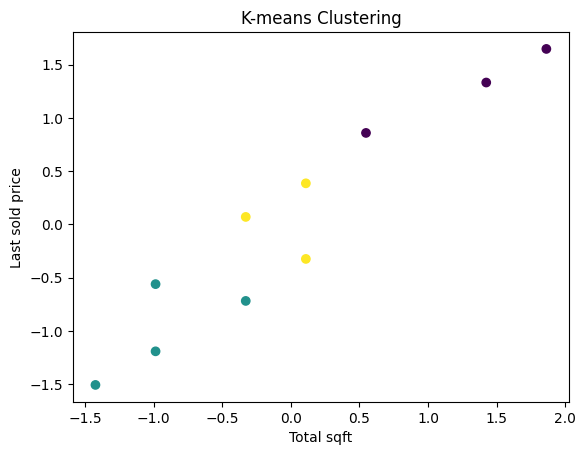

,Lot size,Year built,Last sold price,Finished sqft,Unfinished sqft,Total sqft,Age of the house,House type_Single Family,House type_Townhouse,Parking type_Garage,Heating type_Electric,Cluster
0,-0.953826,1990,-0.717426,1500,500,-0.328502,0.064101,True,False,True,False,1
1,-0.027781,1985,0.070954,1800,200,-0.328502,0.464729,False,True,False,True,2
2,-1.416849,2000,-1.505805,1200,300,-1.423509,-0.737157,False,False,True,False,1
3,0.898264,1975,0.859334,2000,400,0.547504,1.265987,True,False,False,True,0
4,-0.490804,1995,-0.323236,1600,600,0.109501,-0.336528,False,True,True,False,2
5,1.824309,2005,1.647714,2200,800,1.861512,-1.137785,False,False,False,True,0
6,0.435241,1980,0.386306,1700,500,0.109501,0.865358,True,False,True,False,2
7,-1.139035,1998,-1.190453,1300,400,-0.985506,-0.576905,False,True,False,True,1
8,1.083473,1970,1.332362,2100,700,1.423509,1.666615,True,False,True,False,0
9,-0.212990,2010,-0.559750,1400,300,-0.985506,-1.538414,False,False,False,True,1


In [ ]:
# Apply K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df[['Total sqft', 'Last sold price']])

# Visualize the clusters
plt.scatter(df['Total sqft'], df['Last sold price'], c=df['Cluster'], cmap='viridis')
plt.xlabel('Total sqft')
plt.ylabel('Last sold price')
plt.title('K-means Clustering')
plt.show()
df


### 7.2 Hierarchical Clustering

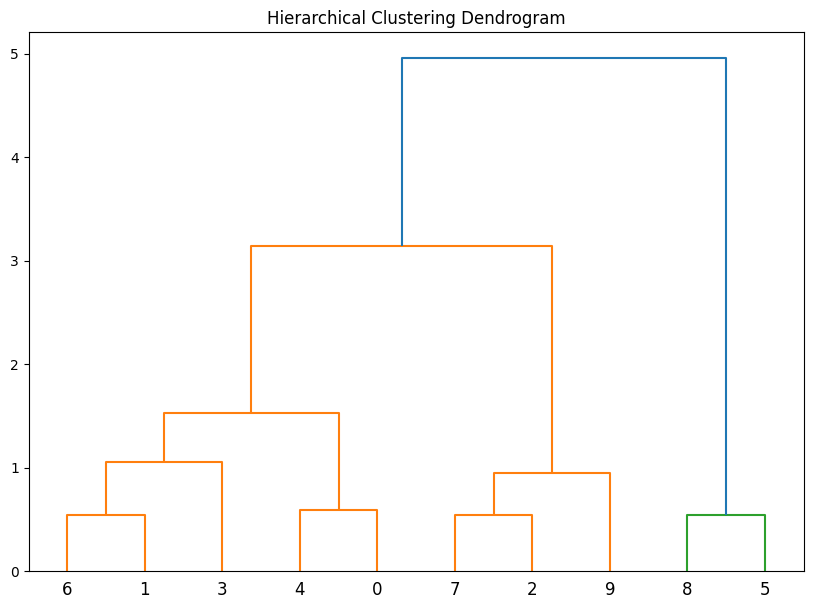

In [ ]:

# Apply hierarchical clustering
linked = linkage(df[['Total sqft', 'Last sold price']], method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', labels=df.index, distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()


## Step 8: Insights Cell

Here, we will analyze the dataset after feature engineering and clustering. We’ll look at:

*   Summary Statistics: Key statistics for numerical features.
* Cluster Analysis: Insights into the clusters formed by K-means.
* Correlation Analysis: Relationships between features.

Here’s the code for that:

In [ ]:
# Insights Cell

### 1. Summary Statistics
print("Summary Statistics for Numerical Features:")
print(df[['Lot size', 'Last sold price', 'Total sqft', 'Age of the house']].describe())

### 2. Cluster Analysis
print("\nCluster Analysis:")
cluster_summary = df.groupby('Cluster').agg({
    'Total sqft': ['mean', 'min', 'max'],
    'Last sold price': ['mean', 'min', 'max'],
    'Age of the house': ['mean', 'min', 'max']
})
print(cluster_summary)

### 3. Correlation Analysis
print("\nCorrelation Matrix:")
corr_matrix = df[['Lot size', 'Last sold price', 'Total sqft', 'Age of the house']].corr()
print(corr_matrix)

Summary Statistics for Numerical Features:
           Lot size  Last sold price    Total sqft  Age of the house
count  1.000000e+01     1.000000e+01  1.000000e+01      1.000000e+01
mean  -2.775558e-18     2.331468e-16  1.332268e-16      2.442491e-16
std    1.054093e+00     1.054093e+00  1.054093e+00      1.054093e+00
min   -1.416849e+00    -1.505805e+00 -1.423509e+00     -1.538414e+00
25%   -8.380707e-01    -6.780066e-01 -8.212554e-01     -6.970939e-01
50%   -1.203859e-01    -1.261408e-01 -1.095007e-01     -1.362138e-01
75%    7.825080e-01     7.410770e-01  4.380029e-01      7.652008e-01
max    1.824309e+00     1.647714e+00  1.861512e+00      1.666615e+00

Cluster Analysis:
        Total sqft                     Last sold price                      \
              mean       min       max            mean       min       max   
Cluster                                                                      
0         1.277508  0.547504  1.861512        1.279803  0.859334  1.647714   
1    

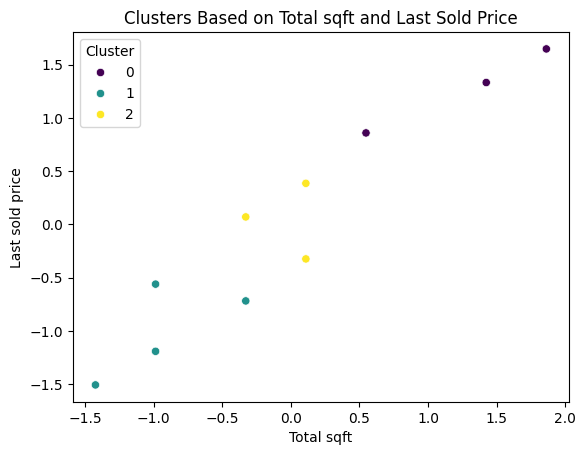

In [ ]:
# Scatter plot for clusters
sns.scatterplot(x='Total sqft', y='Last sold price', hue='Cluster', data=df, palette='viridis')
plt.title('Clusters Based on Total sqft and Last Sold Price')
plt.show()

Cluster Analysis:

Clusters can help identify groups of similar properties. For example:

* Cluster 0 might represent small, affordable houses.

* Cluster 1 might represent large, expensive houses.

* Cluster 2 might represent mid-sized, moderately priced houses.

* There is a linear correlation between Total sqft and Last sold price.

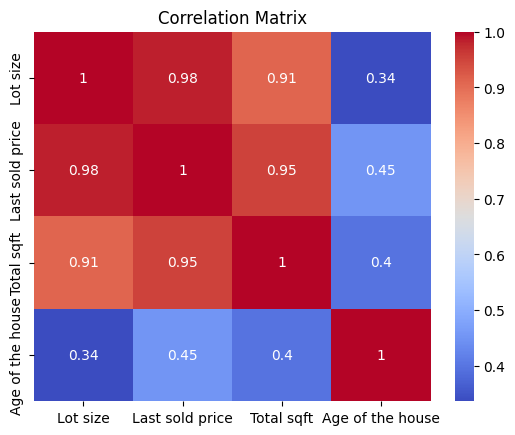

In [ ]:
# Heatmap for correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

This is a correlation matrix (heatmap), which shows the relationships between numerical variables in the dataset.

Here is how to interpret it:
* Lot Size and Last Sold Price (0.98) means a very strong positive correlation. **This means that as the lot size increases, the last sold price tends to increase significantly.**

* Lot Size and Total Sqft (0.91) means a strong positive correlation. **Larger lots tend to have larger total square footage.**

* Last Sold Price and Total Sqft (0.95) means a very strong positive correlation. **Homes with more total square footage tend to be sold at higher prices.**

* Age of the house has a weaker correlation with lot size (0.34), last sold price (0.45), and total sqft (0.4). **This suggests that older homes might be slightly more or less valuable but don’t follow a strong trend.**